In [1]:
import sys
sys.path.append('/home/kstoreyf/muchisimocks/code')

import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

import plotter
import data_loader
import generate_params as genp
import utils_plot

%load_ext autoreload
%autoreload 2


# Inference summary (bx=32)

Compare **noiseless** vs **noisy** inference for:
- mean of fixed cosmology: `shame_p0_n1000`
- coverage test set
- `shame` OOD mock (`nbar=0.00022`)


In [2]:
# Shared configuration
bx = 32
n_train = 10000

data_mode = 'muchisimocks'
TAG_PARAMS_TRAIN = '_p5_n10000'
TAG_BIASPARAMS_TRAIN = '_biasnest_p4_n320000'
TAG_BIASPARAMS_TRAIN_NOISY = '_biasnoisenest_p9_n320000'
TAG_NOISE_TRAIN = '_noise_unit_p5_n10000'

tag_reparam = '_rp'
statistics_arr = [['pk'], ['pk', 'pgm']]
tag_stats_arr = [f'_{"_".join(statistics)}' for statistics in statistics_arr]

extents = {**genp.get_bounds('cosmo'), **genp.get_bounds('bias')}

# Dataset tags
TAG_PARAMS_TEST_FIXED = '_shame_p0_n1000'
TAG_BIASPARAMS_TEST_FIXED = '_biasshame_p0_n1'

TAG_PARAMS_TEST_COV = '_coverage_p5_n1000'
TAG_BIASPARAMS_TEST_COV = '_biascoverage_p4_n1000'
TAG_BIASPARAMS_TEST_COV_NOISY = '_biasnoisecoverage_p9_n1000'
TAG_NOISE_TEST_COV = '_noise_unit_coverage_p5_n1000'

DATA_MODE_TEST_SHAME = 'shame'
TAG_MOCK_SHAME = '_nbar0.00022'

idx_obs = 0


# Noiseless inference

In [3]:
tags_inf_noiseless, labels_noiseless, colors_noiseless, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode,
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN,
    statistics_arr=statistics_arr,
    bx=bx,
    tag_noise=None,
    tag_reparam=tag_reparam,
    n_train=n_train,
)

cosmo_param_names_vary, bias_param_names_vary, param_names_vary = utils_plot.load_training_params(
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN,
    bx=bx,
)

param_names_contour = ['omega_cold', 'sigma8_cold'] + bias_param_names_vary
inf_methods_noiseless = ['sbi'] * len(tags_inf_noiseless)


## Mean of fixed cosmology (`shame_p0_n1000`)

In [4]:
tags_test_fixed_mean = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
    tag_stats_arr=tag_stats_arr,
    tag_noise_test=None,
    tag_datagen_test='_mean',
)

theta_test_fixed = data_loader.load_theta_test(
    TAG_PARAMS_TEST_FIXED,
    TAG_BIASPARAMS_TEST_FIXED,
    cosmo_param_names_vary=cosmo_param_names_vary,
    bias_param_names_vary=bias_param_names_vary,
)

theta_obs_true = theta_test_fixed[idx_obs] if theta_test_fixed.ndim == 2 else theta_test_fixed
idxs_contour = [param_names_vary.index(pn) for pn in param_names_contour]
theta_obs_true_show = theta_obs_true[idxs_contour]


fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000/samples_test_muchisimocks_pk_pgm_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy


Parameter sigma8_cold_x_bl in chain $P_\mathrm{gg}(k)$ is not constrained


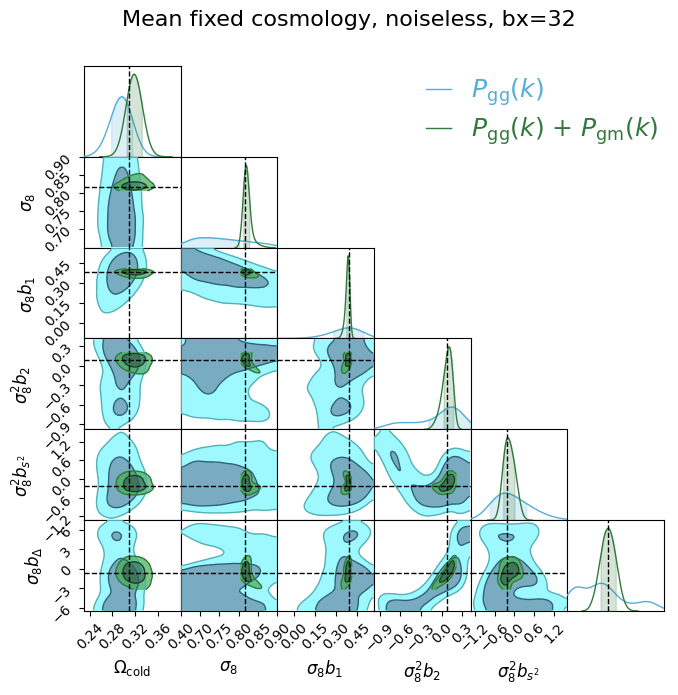

In [5]:
plotter.plot_contours_inf(
    param_names=param_names_contour,
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=inf_methods_noiseless,
    tags_inf=tags_inf_noiseless,
    tags_test=tags_test_fixed_mean,
    colors=colors_noiseless,
    labels=labels_noiseless,
    title=f'Mean fixed cosmology, noiseless, bx={bx}',
    extents=extents,
)


## Coverage test set

In [10]:
tags_test_cov = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_COV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_COV,
    tag_stats_arr=tag_stats_arr,
    tag_noise_test=TAG_NOISE_TEST_COV,
    tag_datagen_test='',
)

theta_cov = data_loader.load_theta_test(
    TAG_PARAMS_TEST_COV,
    TAG_BIASPARAMS_TEST_COV,
    cosmo_param_names_vary=cosmo_param_names_vary,
    bias_param_names_vary=bias_param_names_vary,
)

theta_obs_true = theta_cov[idx_obs] if theta_cov.ndim == 2 else theta_cov
idxs_contour = [param_names_vary.index(pn) for pn in param_names_contour]
theta_obs_true_show = theta_obs_true[idxs_contour]


fn_samples_test_pred = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000/samples_test_muchisimocks_pk_coverage_p5_n1000_biascoverage_p4_n1000_pred.npy
fn_samples_test_pred = ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000/samples_test_muchisimocks_pk_pgm_coverage_p5_n1000_biascoverage_p4_n1000_pred.npy


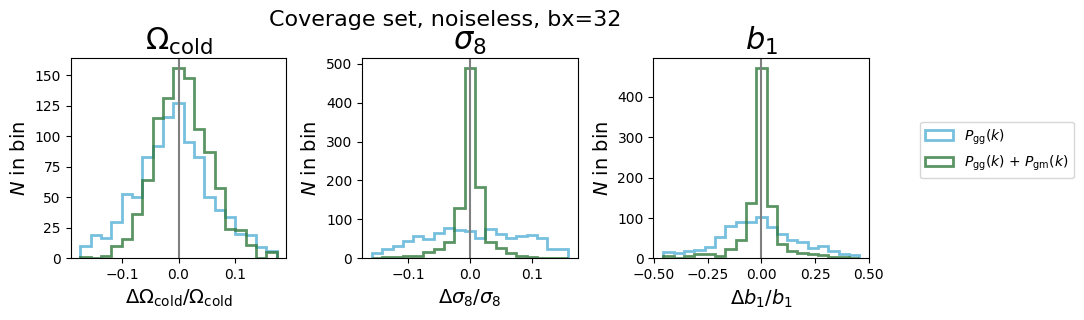

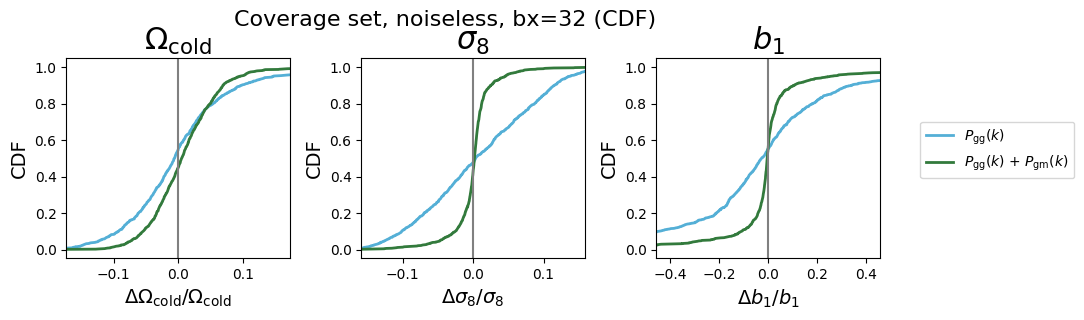

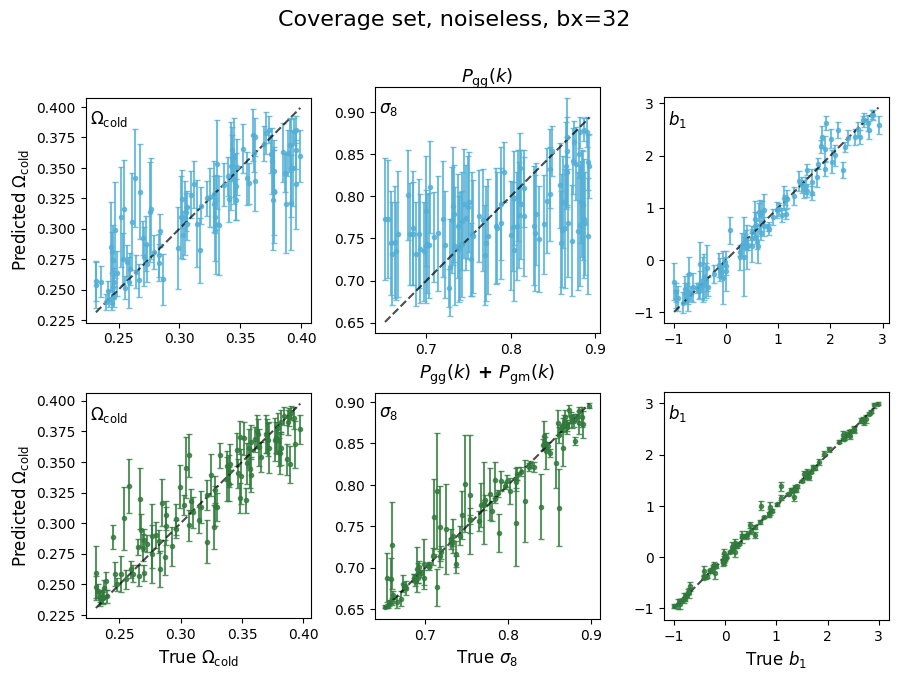

(<Figure size 900x700 with 6 Axes>,
 array([[<Axes: ylabel='Predicted $\\Omega_\\mathrm{cold}$'>, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='True $\\Omega_\\mathrm{cold}$', ylabel='Predicted $\\Omega_\\mathrm{cold}$'>,
         <Axes: xlabel='True $\\sigma_{8}$'>, <Axes: xlabel='True $b_1$'>]],
       dtype=object))

In [11]:
# Coverage set: non-contour distribution + comparison plots
# Always plot in the unreparameterized `param_names_key` space.
param_names_key, param_names_key_rp = utils_plot.get_param_names_key()

# Build noiseless coverage test tags (exclude `tag_noise_test` / noise-unit term)
# (i.e. match the noiseless inference outputs.)
tags_test_cov_noiseless = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_COV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_COV,
    tag_stats_arr=tag_stats_arr,
    tag_noise_test=None,
    tag_datagen_test='',
)

theta_true_arr, theta_pred_arr, vars_pred_arr, covs_pred_arr, _ = utils_plot.load_test_predictions(
    tags_inf=tags_inf_noiseless,
    tags_data_test=tags_test_cov_noiseless,
    tag_params_test=TAG_PARAMS_TEST_COV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_COV,
    cosmo_param_names_vary=cosmo_param_names_vary,
    bias_param_names_vary=bias_param_names_vary,
    param_names_vary=param_names_vary,
    tag_reparam=tag_reparam,
    param_names_show=param_names_key_rp,
)

plotter.plot_dists_mean_subplots(
    theta_pred_arr,
    theta_true_arr,
    param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_noiseless,
    label_arr=labels_noiseless,
    n_bins=20,
    alpha=0.8,
    histtype='step',
    xlim_auto=False,
    plot_cdf=False,
    unreparameterize=True,
    title=f'Coverage set, noiseless, bx={bx}',
)

plotter.plot_dists_mean_subplots(
    theta_pred_arr,
    theta_true_arr,
    param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_noiseless,
    label_arr=labels_noiseless,
    n_bins=20,
    alpha=0.8,
    histtype='step',
    xlim_auto=False,
    plot_cdf=True,
    unreparameterize=True,
    title=f'Coverage set, noiseless, bx={bx} (CDF)',
)

plotter.plot_comp_mean_subplots_grid(
    statistics_arr,
    theta_pred_arr,
    theta_true_arr,
    covs_pred_arr,
    param_names=param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_noiseless,
    label_arr=labels_noiseless,
    alpha=0.8,
    N_plot=100,
    unreparameterize=True,
    title=f'Coverage set, noiseless, bx={bx}',
)


## SHAMe mock

In [ ]:
tags_test_shame = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=tag_stats_arr,
    data_mode_test=DATA_MODE_TEST_SHAME,
    tag_mock=TAG_MOCK_SHAME,
)

theta_ood = data_loader.load_theta_ood(
    DATA_MODE_TEST_SHAME,
    TAG_MOCK_SHAME,
    cosmo_param_names_vary=cosmo_param_names_vary,
    bias_param_names_vary=bias_param_names_vary,
)

theta_obs_true = theta_ood[idx_obs] if theta_ood.ndim == 2 else theta_ood
idxs_contour = [param_names_vary.index(pn) for pn in param_names_contour]
theta_obs_true_show = theta_obs_true[idxs_contour]


fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
ERROR: missing samples (inf_method=sbi, tag_inf=_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000, tag_test=_shame_pk_pgm_nbar0.00022): ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000/samples_test_shame_pk_pgm_nbar0.00022_pred.npy


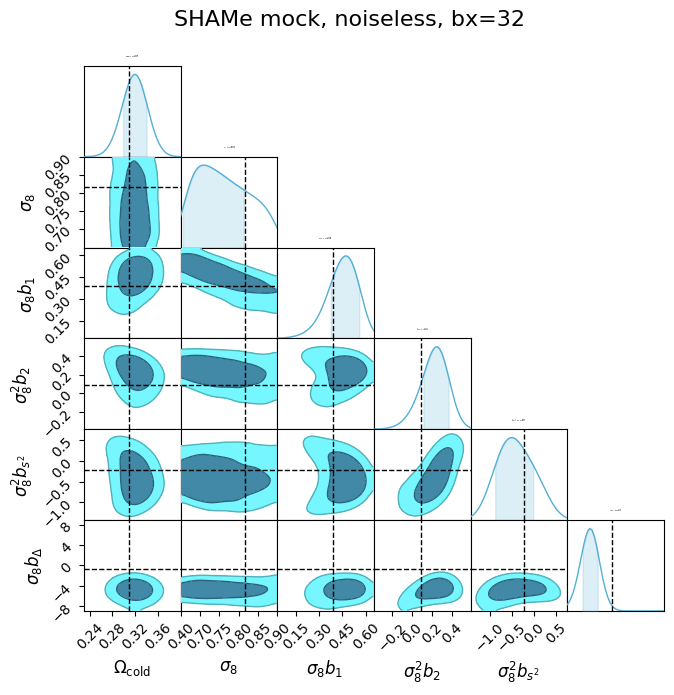

In [ ]:
plotter.plot_contours_inf(
    param_names=param_names_contour,
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=inf_methods_noiseless,
    tags_inf=tags_inf_noiseless,
    tags_test=tags_test_shame,
    colors=colors_noiseless,
    labels=labels_noiseless,
    title=f'SHAMe mock, noiseless, bx={bx}',
    extents=extents,
)


# Noisy inference

In [ ]:
tags_inf_noisy, labels_noisy, colors_noisy, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode,
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
    statistics_arr=statistics_arr,
    bx=bx,
    tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam,
    n_train=n_train,
)

cosmo_param_names_vary_n, bias_param_names_vary_n, param_names_vary_n = utils_plot.load_training_params(
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
    bx=bx,
)

param_names_contour_n = ['omega_cold', 'sigma8_cold'] + bias_param_names_vary_n
inf_methods_noisy = ['sbi'] * len(tags_inf_noisy)


## Mean of fixed cosmology (`shame_p0_n1000`)

In [ ]:
tags_test_fixed_mean = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
    tag_stats_arr=tag_stats_arr,
    tag_noise_test=None,
    tag_datagen_test='_mean',
)

theta_test_fixed = data_loader.load_theta_test(
    TAG_PARAMS_TEST_FIXED,
    TAG_BIASPARAMS_TEST_FIXED,
    cosmo_param_names_vary=cosmo_param_names_vary_n,
    bias_param_names_vary=bias_param_names_vary_n,
)

theta_obs_true = theta_test_fixed[idx_obs] if theta_test_fixed.ndim == 2 else theta_test_fixed
idxs_contour = [param_names_vary_n.index(pn) for pn in param_names_contour_n]
theta_obs_true_show = theta_obs_true[idxs_contour]


In [ ]:
plotter.plot_contours_inf(
    param_names=param_names_contour_n,
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=inf_methods_noisy,
    tags_inf=tags_inf_noisy,
    tags_test=tags_test_fixed_mean,
    colors=colors_noisy,
    labels=labels_noisy,
    title=f'Mean fixed cosmology, noisy, bx={bx}',
    extents=extents,
)


fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
ERROR: missing samples (inf_method=sbi, tag_inf=_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000, tag_test=_muchisimocks_pk_shame_p0_n1000_biasshame_p0_n1_mean): ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000/samples_test_muchisimocks_pk_pgm_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
ERROR: missing samples (inf_method=sbi, tag_inf=_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000, tag_test=_muchisimocks_pk_pgm_shame

## Coverage test set

In [ ]:
tags_test_cov = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_COV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_COV_NOISY,
    tag_stats_arr=tag_stats_arr,
    tag_noise_test=TAG_NOISE_TEST_COV,
    tag_datagen_test='',
)

theta_cov = data_loader.load_theta_test(
    TAG_PARAMS_TEST_COV,
    TAG_BIASPARAMS_TEST_COV_NOISY,
    cosmo_param_names_vary=cosmo_param_names_vary_n,
    bias_param_names_vary=bias_param_names_vary_n,
)

theta_obs_true = theta_cov[idx_obs] if theta_cov.ndim == 2 else theta_cov
idxs_contour = [param_names_vary_n.index(pn) for pn in param_names_contour_n]
theta_obs_true_show = theta_obs_true[idxs_contour]


fn_samples_test_pred = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000/samples_test_muchisimocks_pk_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy


fn_samples_test_pred = ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000/samples_test_muchisimocks_pk_pgm_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy


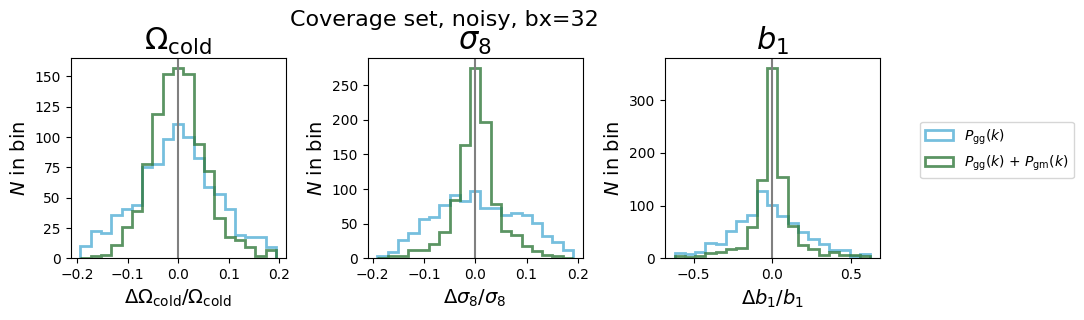

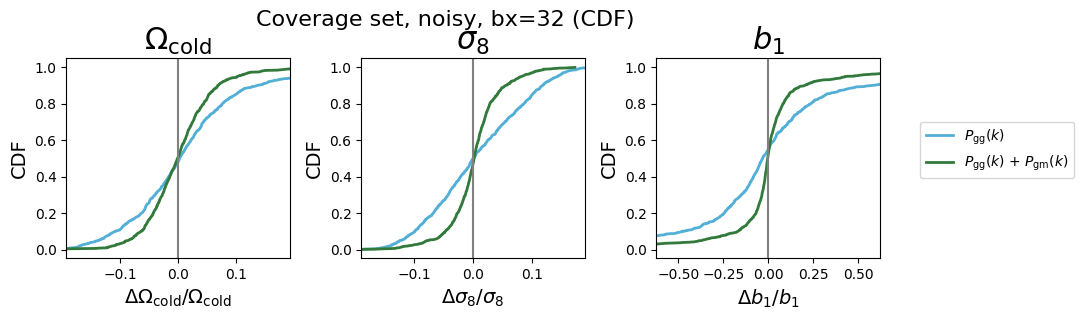

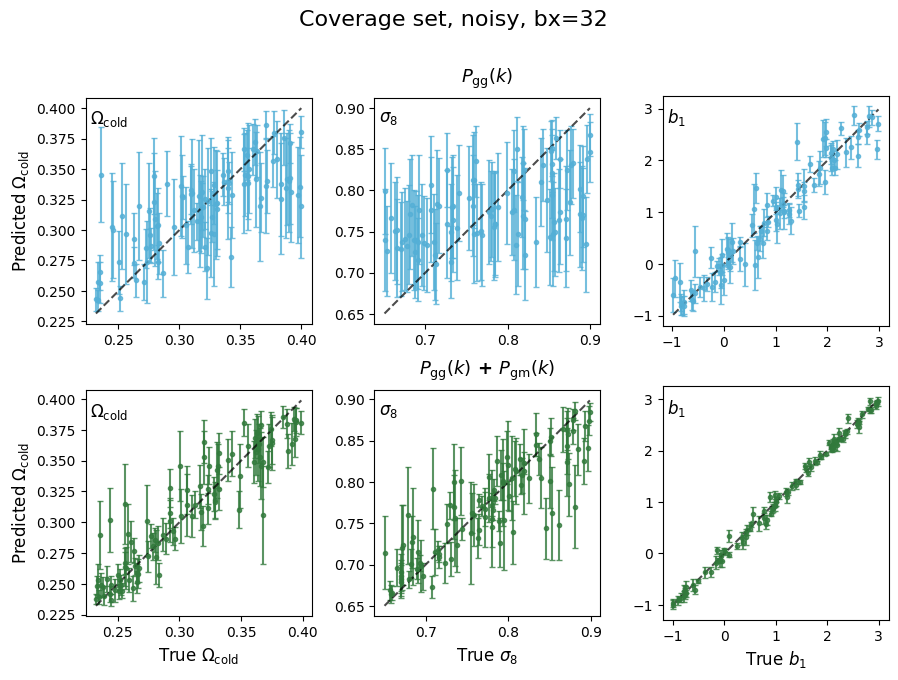

(<Figure size 900x700 with 6 Axes>,
 array([[<Axes: ylabel='Predicted $\\Omega_\\mathrm{cold}$'>, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='True $\\Omega_\\mathrm{cold}$', ylabel='Predicted $\\Omega_\\mathrm{cold}$'>,
         <Axes: xlabel='True $\\sigma_{8}$'>, <Axes: xlabel='True $b_1$'>]],
       dtype=object))

In [ ]:
# Coverage set: non-contour distribution + comparison plots
# Always plot in the unreparameterized `param_names_key` space.
param_names_key, param_names_key_rp = utils_plot.get_param_names_key()

theta_true_arr, theta_pred_arr, vars_pred_arr, covs_pred_arr, _ = utils_plot.load_test_predictions(
    tags_inf=tags_inf_noisy,
    tags_data_test=tags_test_cov,
    tag_params_test=TAG_PARAMS_TEST_COV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_COV_NOISY,
    cosmo_param_names_vary=cosmo_param_names_vary_n,
    bias_param_names_vary=bias_param_names_vary_n,
    param_names_vary=param_names_vary_n,
    tag_reparam=tag_reparam,
    param_names_show=param_names_key_rp,
)

plotter.plot_dists_mean_subplots(
    theta_pred_arr,
    theta_true_arr,
    param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_noisy,
    label_arr=labels_noisy,
    n_bins=20,
    alpha=0.8,
    histtype='step',
    xlim_auto=False,
    plot_cdf=False,
    unreparameterize=True,
    title=f'Coverage set, noisy, bx={bx}',
)

plotter.plot_dists_mean_subplots(
    theta_pred_arr,
    theta_true_arr,
    param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_noisy,
    label_arr=labels_noisy,
    n_bins=20,
    alpha=0.8,
    histtype='step',
    xlim_auto=False,
    plot_cdf=True,
    unreparameterize=True,
    title=f'Coverage set, noisy, bx={bx} (CDF)',
)

plotter.plot_comp_mean_subplots_grid(
    statistics_arr,
    theta_pred_arr,
    theta_true_arr,
    covs_pred_arr,
    param_names=param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_noisy,
    label_arr=labels_noisy,
    alpha=0.8,
    N_plot=100,
    unreparameterize=True,
    title=f'Coverage set, noisy, bx={bx}',
)


## SHAMe mock

In [ ]:
tags_test_shame = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=tag_stats_arr,
    data_mode_test=DATA_MODE_TEST_SHAME,
    tag_mock=TAG_MOCK_SHAME,
)

theta_ood = data_loader.load_theta_ood(
    DATA_MODE_TEST_SHAME,
    TAG_MOCK_SHAME,
    cosmo_param_names_vary=cosmo_param_names_vary_n,
    bias_param_names_vary=bias_param_names_vary_n,
)

theta_obs_true = theta_ood[idx_obs] if theta_ood.ndim == 2 else theta_ood
idxs_contour = [param_names_vary_n.index(pn) for pn in param_names_contour_n]
theta_obs_true_show = theta_obs_true[idxs_contour]


fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000/samples_test_shame_pk_pgm_nbar0.00022_pred.npy


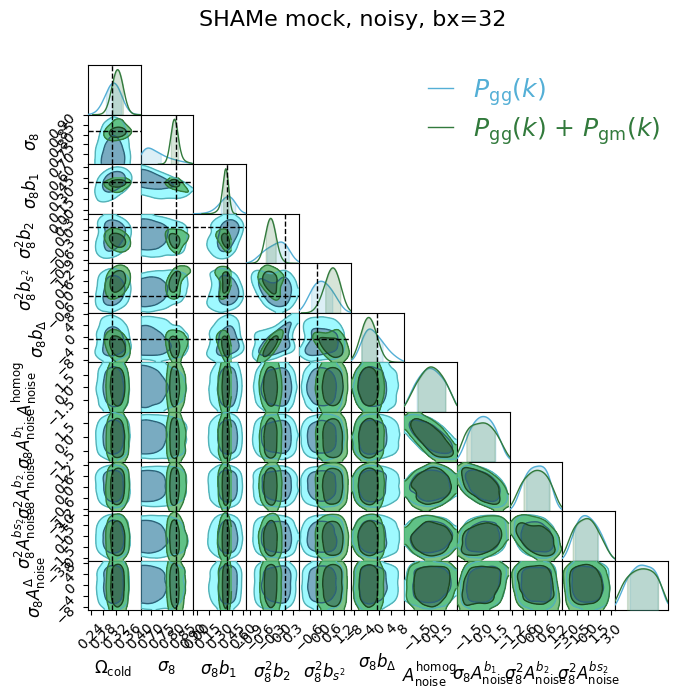

In [ ]:
plotter.plot_contours_inf(
    param_names=param_names_contour_n,
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=inf_methods_noisy,
    tags_inf=tags_inf_noisy,
    tags_test=tags_test_shame,
    colors=colors_noisy,
    labels=labels_noisy,
    title=f'SHAMe mock, noisy, bx={bx}',
    extents=extents,
)
